# LCPB 25-26 Exercise 3, XGBoost (XGB)
## 1. Model complexity, parameters' and regularization
Try different parameters ($\lambda$, $\gamma$, n_estimators, ...). Which is the simplest yet effective XGB model that keeps a good validation accuracy? Is regularization useful for this analysis?

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib as mpl

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


### Hyperparameter search using GridSearchCV
We explore different values for `n_estimators`, `max_depth`, `gamma`, and `reg_lambda` to find the simplest yet effective configuration.

In [7]:
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'gamma': [0, 0.05, 0.1, 1],
    'reg_lambda': [1, 10, 50, 100]
}


xgb = XGBClassifier(eval_metric='logloss', seed=1)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(x_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 320 candidates, totalling 960 fits
Best parameters found: {'gamma': 0, 'max_depth': 9, 'n_estimators': 200, 'reg_lambda': 1}
Best CV accuracy: 0.9224


In [8]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
val_accuracy = accuracy_score(y_test, y_pred)
print("Validation accuracy of the best model:", val_accuracy)

Validation accuracy of the best model: 0.9416


### Is regularization useful for this analysis?
Let's explore the effect of `reg_lambda` on the accuracy by plotting the validation accuracy for different lambda values, keeping other hyperparameters fixed.

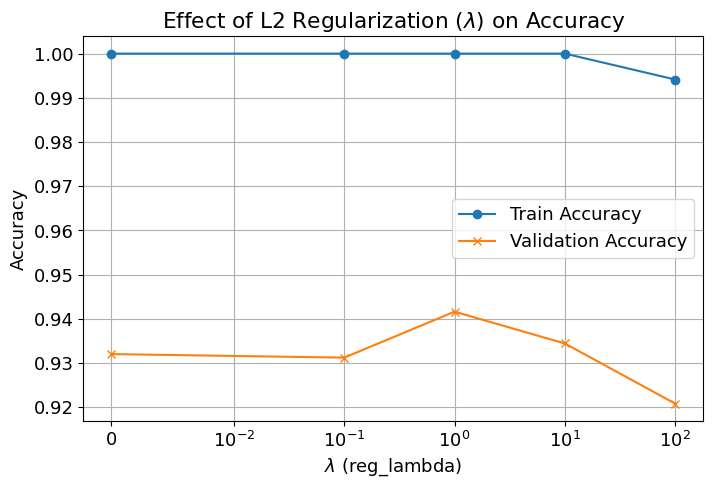

In [10]:
lambdas = [0, 0.1, 1, 10, 100]
train_accuracies = []
val_accuracies = []

best_n_estimators = grid_search.best_params_['n_estimators']
best_max_depth = grid_search.best_params_['max_depth']
best_gamma = grid_search.best_params_['gamma']

for reg_lambda in lambdas:
    model = XGBClassifier(eval_metric='logloss', seed=1, 
                          n_estimators=best_n_estimators, 
                          max_depth=best_max_depth,
                          gamma=best_gamma,
                          reg_lambda=reg_lambda)
    model.fit(x_train, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(x_train)))
    val_accuracies.append(accuracy_score(y_test, model.predict(x_test)))

plt.figure(figsize=(8, 5))
plt.plot(lambdas, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(lambdas, val_accuracies, marker='x', label='Validation Accuracy')
plt.xscale('symlog', linthresh=0.01)
plt.xlabel(r'$\lambda$ (reg_lambda)')
plt.ylabel('Accuracy')
plt.title(r'Effect of L2 Regularization ($\lambda$) on Accuracy')
plt.legend()
plt.grid()
plt.show()

Regularization is useful as it prevents the training score from diverging too far from the validation score (overfitting), achieving the highest validation score at optimal lambda. The plot demonstrates the validation accuracy responding favorably to appropriate regularization values.